In [8]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.combine import SMOTETomek

In [9]:
data_path = "early_wakeup_health_dataset.csv"

df = pd.read_csv(data_path)

df.head()

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Country,Occupation,Marital_Status,Wake_Up_Time,...,Obesity_Risk,Hypertension_Risk,Diabetes_Risk,Cardiovascular_Risk,Sleep_Disorder_Risk,Health_Score,Fitness_Level,Healthy_Aging_Score,Wellness_Category,Early_Waker
0,P00001,76,Female,158.8,62.1,24.63,Italy,Entrepreneur,Widowed,08:59,...,Low,High,Medium,Medium,Low,87.3,Excellent,81.8,Excellent,No
1,P00002,49,Female,160.9,68.5,26.45,USA,Freelancer,Single,06:35,...,Medium,Medium,Medium,Low,Medium,72.0,Good,75.2,Good,No
2,P00003,51,Female,151.9,54.8,23.77,Mexico,Nurse,Single,07:31,...,Low,Medium,Medium,Low,Low,75.2,Good,77.1,Good,No
3,P00004,48,Male,167.6,81.3,28.93,Australia,Laborer,Single,08:36,...,Medium,Medium,Low,Low,Medium,82.7,Excellent,87.1,Excellent,No
4,P00005,68,Female,171.9,75.4,25.51,USA,Software Engineer,Married,07:07,...,Medium,High,Medium,Medium,Low,62.7,Average,58.1,Average,No


In [10]:
# Reading Missing Values
print(f"Readning Null : {df.isnull().sum().max()}")

Readning Null : 3014


Exercise_Type           824
Workout_Intensity       824
Alcohol_Consumption    3014
dtype: int64


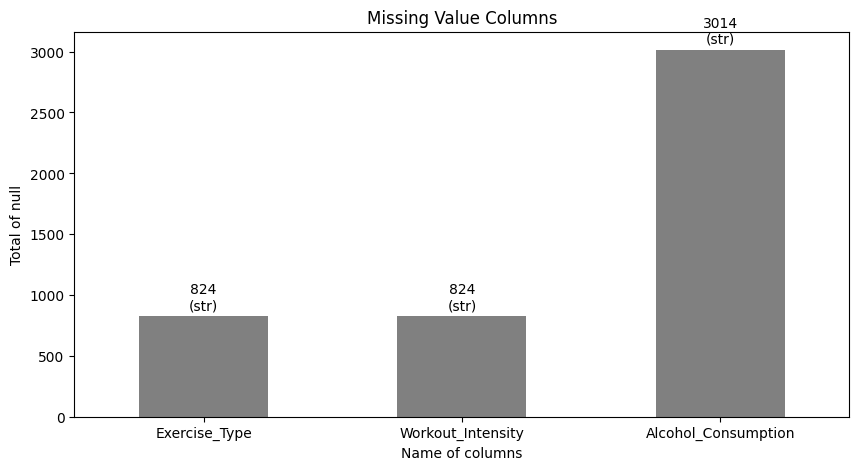

In [11]:
# Searching for null fields

missing_value = df.isnull().sum()[df.isnull().sum() > 0]

missing_types = df[missing_value.index].dtypes

print(df.isnull().sum()[df.isnull().sum() > 0])

plt.figure(figsize=(10,5))

ax = missing_value.plot.bar(color='gray')

for i, col in enumerate(missing_value.index):
    count = missing_value[col]
    dtype = missing_types[col]

    ax.text(i, count + (max(missing_value) * 0.01), f"{count}\n({dtype})", ha='center', va='bottom')

plt.title("Missing Value Columns")
plt.xlabel("Name of columns")
plt.ylabel("Total of null")
plt.xticks(rotation=0)
plt.show()